CELL 1: Imports and Setup

In [9]:
# ============================================================
# PHASE 8 & 9: EDA + RAG-SAFE DATA CLEANING
# ============================================================
# Outputs feed Phase 10–14:
#   text_for_ml / questions_for_ml.csv  -> labeling, features, training
#   text_for_rag / conversations_for_rag.csv -> ChromaDB embeddings
#   text_original -> audit trail
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PLOT_COLOR = '#1f77b4'

print("=" * 60)
print("PHASE 8 & 9: EDA + RAG-SAFE CLEANING")
print("=" * 60)

PHASE 8 & 9: EDA + RAG-SAFE CLEANING


CELL 2: Load Full Datasets

In [2]:
# ============================================================
# LOAD DATA (memory-aware)
# - Raw: 200k-row sample for column demos + same schema as full raw
# - Raw tweet_id column only: full file, for verification
# - Enhanced: FULL (required for EDA + cleaning outputs)
# ============================================================

RAW_SAMPLE_ROWS = 200_000

raw_path = Path("../data/raw/twcs.csv")
enhanced_path = Path("../data/processed/twcs_enhanced.csv")

print("\n[1/11] Loading datasets...")
print(f"Raw: {raw_path} ({raw_path.stat().st_size / (1024**3):.2f} GB)")
print(f"Enhanced: {enhanced_path} ({enhanced_path.stat().st_size / (1024**3):.2f} GB)")

raw_dtypes = {
    'tweet_id': 'int32',
    'author_id': 'object',
    'inbound': 'bool',
    'created_at': 'object',
    'text': 'object',
    'response_tweet_id': 'object',
    'in_response_to_tweet_id': 'object',
}

df_raw_sample = pd.read_csv(
    raw_path, nrows=RAW_SAMPLE_ROWS, dtype=raw_dtypes, low_memory=False
)
print(f"  Raw sample (EDA / schema): {len(df_raw_sample):,} rows")

print("  Loading ALL raw tweet_id (single column) for verification...")
raw_ids = pd.read_csv(
    raw_path, usecols=['tweet_id'], dtype={'tweet_id': 'int32'}, low_memory=False
)['tweet_id'].to_numpy()

print("  Loading FULL enhanced dataset...")
df_enhanced = pd.read_csv(enhanced_path, low_memory=False)
enh_ids = df_enhanced['tweet_id'].to_numpy()

print(f"\n✅ Raw tweet_id count: {len(raw_ids):,}")
print(f"✅ Enhanced: {len(df_enhanced):,} rows, {df_enhanced.shape[1]} columns")


[1/11] Loading datasets...
Raw: ..\data\raw\twcs.csv (0.48 GB)
Enhanced: ..\data\processed\twcs_enhanced.csv (0.59 GB)
  Raw sample (EDA / schema): 200,000 rows
  Loading ALL raw tweet_id (single column) for verification...
  Loading FULL enhanced dataset...

✅ Raw tweet_id count: 2,811,774
✅ Enhanced: 2,811,774 rows, 14 columns


CELL 3: VERIFICATION - All Raw Data Exists in Enhanced

In [4]:
# ============================================================
# VERIFICATION: every raw tweet_id appears in enhanced (multiset)
# Uses sorted arrays — avoids huge Python sets
# ============================================================

print("\n[2/11] VERIFICATION: raw tweet_ids vs enhanced...")

same_len = len(raw_ids) == len(enh_ids)
sorted_match = same_len and np.array_equal(np.sort(raw_ids), np.sort(enh_ids))

print(f"\n📊 Row / multiset check:")
print(f"   Raw tweet_id rows: {len(raw_ids):,}")
print(f"   Enhanced rows:     {len(enh_ids):,}")
print(f"   Sorted arrays match: {sorted_match}")

if sorted_match:
    print("\n✅ ALL raw tweet_ids present in enhanced (no extras/missing).")
    print("=" * 60)
    print("✅✅✅ VERIFICATION PASSED ✅✅✅")
    print("=" * 60)
    VERIFIED = True
else:
    print("\n❌ VERIFICATION FAILED — investigate raw vs enhanced.")
    VERIFIED = False


[2/11] VERIFICATION: raw tweet_ids vs enhanced...

📊 Row / multiset check:
   Raw tweet_id rows: 2,811,774
   Enhanced rows:     2,811,774
   Sorted arrays match: True

✅ ALL raw tweet_ids present in enhanced (no extras/missing).
✅✅✅ VERIFICATION PASSED ✅✅✅


CELL 4: If Verified, Show New Columns

In [5]:
# ============================================================
# SHOW NEW COLUMNS IN ENHANCED DATASET
# ============================================================

if VERIFIED:
    print("\n[3/11] Enhanced dataset - new columns added:")
    
    raw_cols = set(df_raw_sample.columns)
    enhanced_cols = set(df_enhanced.columns)
    new_cols = enhanced_cols - raw_cols
    
    print(f"\n📊 Total new columns: {len(new_cols)}")
    for col in sorted(new_cols):
        print(f"   - {col}")
        
        # Show sample values
        sample_vals = df_enhanced[col].dropna().head(3).tolist()
        print(f"     Sample: {sample_vals}")
    
    # Columns removed (should be none)
    removed_cols = raw_cols - enhanced_cols
    if removed_cols:
        print(f"\n⚠️ Columns removed: {removed_cols}")
    else:
        print(f"\n✅ No columns removed - all original columns preserved")
else:
    print("\n⚠️ Skipping - verification failed. Check data integrity first.")


[3/11] Enhanced dataset - new columns added:

📊 Total new columns: 7
   - conversation_id
     Sample: [0, 0, 0]
   - has_response
     Sample: [True, True, True]
   - is_question
     Sample: [True, False, False]
   - parent_tweet_id
     Sample: [9.0, 5.0, 4.0]
   - position_in_conversation
     Sample: [1, 2, 3]
   - response_tweet_ids
     Sample: ['[6, 9, 10]', '[8]', '[8]']
   - total_tweets_in_conversation
     Sample: [10, 10, 10]

✅ No columns removed - all original columns preserved


CELL 5: Conversation Statistics (EDA)


[4/11] Conversation statistics (full enhanced)...

Conversation statistics table:
       metric         value
conversations 798012.000000
  mean_tweets      3.523473
median_tweets      2.000000
          std      5.158453
          min      2.000000
          max   1390.000000
          p50      2.000000
          p75      4.000000
          p90      6.000000
          p95      8.000000
          p99     15.000000


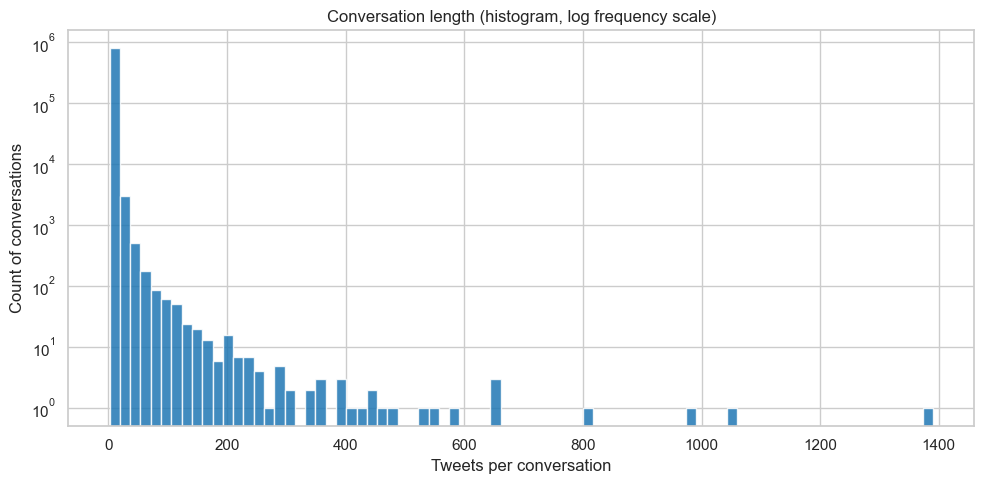

In [6]:
# ============================================================
# CONVERSATION STATISTICS (EDA) — FULL enhanced dataset
# ============================================================

if VERIFIED:
    print("\n[4/11] Conversation statistics (full enhanced)...")

    conv_lengths = df_enhanced.groupby('conversation_id').size()

    stats_tbl = pd.DataFrame({
        'metric': ['conversations', 'mean_tweets', 'median_tweets', 'std', 'min', 'max',
                   'p50', 'p75', 'p90', 'p95', 'p99'],
        'value': [
            df_enhanced['conversation_id'].nunique(),
            conv_lengths.mean(),
            conv_lengths.median(),
            conv_lengths.std(),
            conv_lengths.min(),
            conv_lengths.max(),
            conv_lengths.quantile(0.50),
            conv_lengths.quantile(0.75),
            conv_lengths.quantile(0.90),
            conv_lengths.quantile(0.95),
            conv_lengths.quantile(0.99),
        ],
    })
    print("\nConversation statistics table:")
    print(stats_tbl.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(conv_lengths, bins=80, color=PLOT_COLOR, edgecolor='white', alpha=0.85)
    ax.set_xlabel('Tweets per conversation')
    ax.set_ylabel('Count of conversations')
    ax.set_yscale('log')
    ax.set_title('Conversation length (histogram, log frequency scale)')
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Skipping — verification failed.")

CELL 6: Inbound vs Outbound Analysis


[5/11] Inbound vs outbound (full enhanced)...

📊 Customer tweets (inbound=True):  1,537,843 (54.7%)
📊 Brand tweets (inbound=False):    1,273,931 (45.3%)


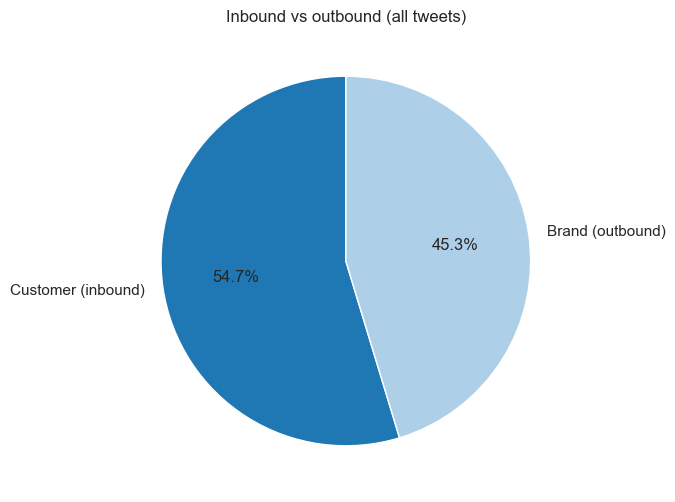


📊 Response coverage (is_question rows, has_response):
   With answer:    1,537,843 (100.0%)
   Without answer: 0 (0.0%)

📊 Tweets with comma-separated response_tweet_id: 222,426 (7.91%)


In [7]:
# ============================================================
# INBOUND VS OUTBOUND — customer (inbound) vs brand (outbound)
# Response coverage: customer rows flagged as questions (is_question)
# ============================================================

if VERIFIED:
    print("\n[5/11] Inbound vs outbound (full enhanced)...")

    cust = (df_enhanced['inbound'] == True).sum()
    brand = (df_enhanced['inbound'] == False).sum()
    n = len(df_enhanced)

    print(f"\n📊 Customer tweets (inbound=True):  {cust:,} ({cust/n*100:.1f}%)")
    print(f"📊 Brand tweets (inbound=False):    {brand:,} ({brand/n*100:.1f}%)")

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(
        [cust, brand],
        labels=['Customer (inbound)', 'Brand (outbound)'],
        autopct='%1.1f%%',
        colors=[PLOT_COLOR, '#aecfe8'],
        startangle=90,
    )
    ax.set_title('Inbound vs outbound (all tweets)')
    plt.show()

    questions = df_enhanced[df_enhanced['is_question'] == True]
    qw = questions[questions['has_response'] == True]
    nq = len(questions)
    if nq:
        cov = len(qw) / nq * 100
        print(f"\n📊 Response coverage (is_question rows, has_response):")
        print(f"   With answer:    {len(qw):,} ({cov:.1f}%)")
        print(f"   Without answer: {nq - len(qw):,} ({100 - cov:.1f}%)")
    else:
        print("\n⚠️ No rows with is_question=True")

    multi = df_enhanced['response_tweet_id'].astype(str).str.contains(',', na=False).sum()
    print(f"\n📊 Tweets with comma-separated response_tweet_id: {multi:,} ({multi/n*100:.2f}%)")
else:
    print("\n⚠️ Skipping — verification failed.")

CELL 7: Text Analysis (Before Cleaning)


[6/11] Text analysis before cleaning (is_question rows)...
   Question rows: 1,537,843

📊 Question text length (chars)
   Mean: 109.9  Median: 109
   Min: 1  Max: 513

📊 Exclamation marks per question
   Mean: 0.28
   % with ≥1: 16.2%
   % with ≥3: 2.6%

📊 Question marks per question
   Mean: 0.34
   % with ≥1: 25.9%

📊 ALL CAPS ratio (upper / alphabetic)
   Mean: 0.087
   % with >0.3: 2.2%

📊 @mentions per question
   Mean: 1.27
   % with ≥1 @: 96.3%

📊 URLs (http/https/www/t.co substring)
   % rows with URL-like token: 14.0%


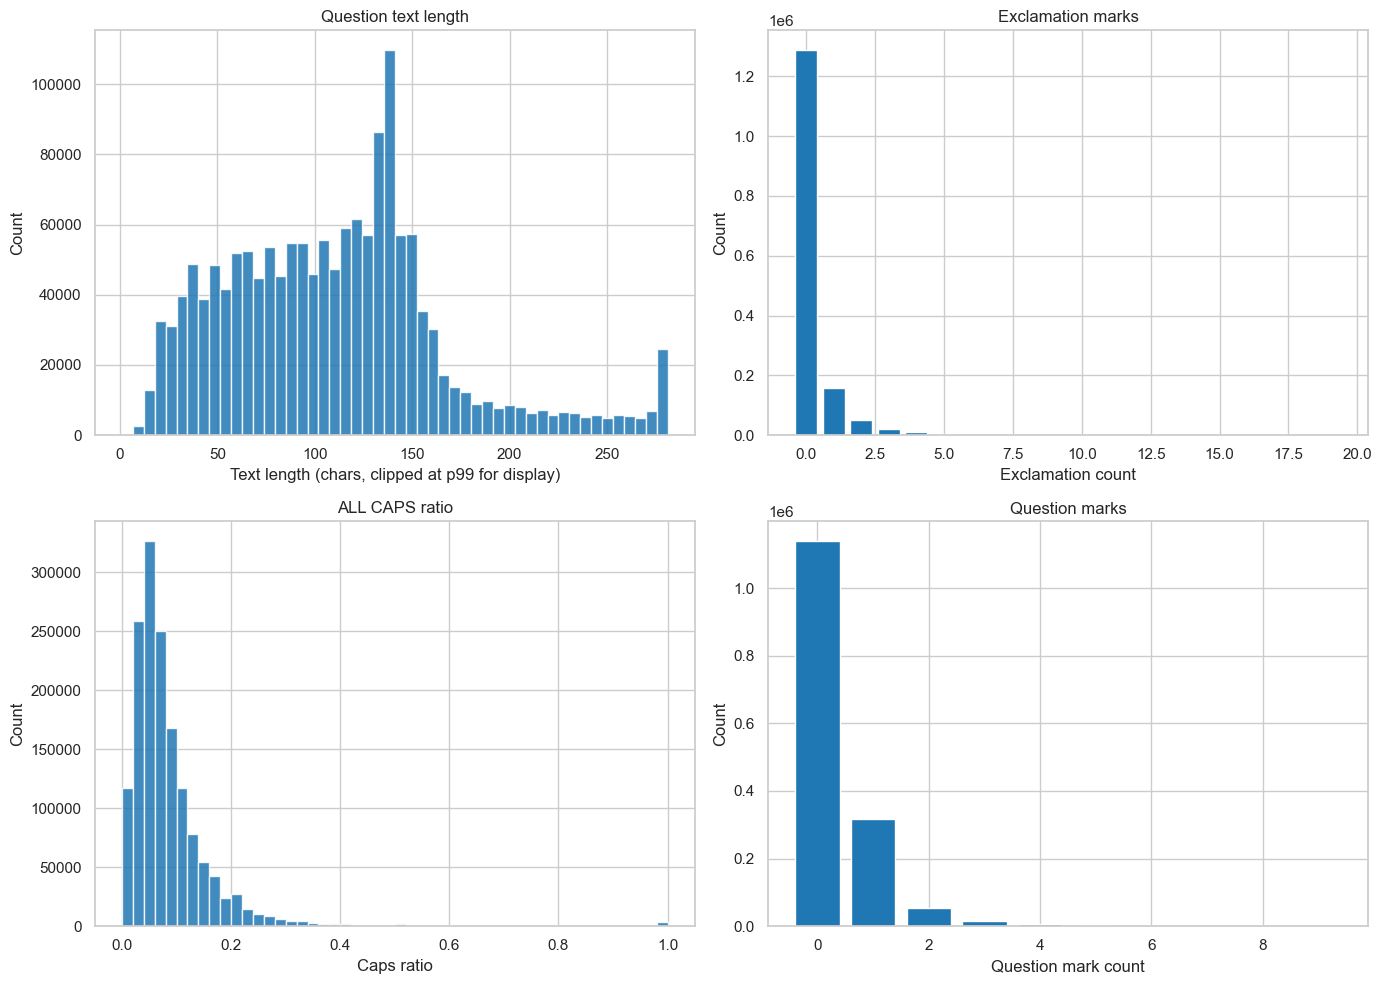

In [8]:
# ============================================================
# TEXT ANALYSIS (BEFORE CLEANING)
# Vectorized on ALL rows with is_question (Phase 10–11 signals)
# ============================================================

if VERIFIED:
    print("\n[6/11] Text analysis before cleaning (is_question rows)...")

    qt = df_enhanced.loc[df_enhanced['is_question'] & df_enhanced['text'].notna(), 'text']
    n_q = len(qt)
    print(f"   Question rows: {n_q:,}")

    if n_q == 0:
        print("No question text found.")
    else:
        text_lengths = qt.str.len()
        print("\n📊 Question text length (chars)")
        print(f"   Mean: {text_lengths.mean():.1f}  Median: {text_lengths.median():.0f}")
        print(f"   Min: {text_lengths.min():.0f}  Max: {text_lengths.max():.0f}")

        excl = qt.str.count('!')
        qm = qt.str.count(r'\?')
        print("\n📊 Exclamation marks per question")
        print(f"   Mean: {excl.mean():.2f}")
        print(f"   % with ≥1: {(excl > 0).mean() * 100:.1f}%")
        print(f"   % with ≥3: {(excl >= 3).mean() * 100:.1f}%")

        print("\n📊 Question marks per question")
        print(f"   Mean: {qm.mean():.2f}")
        print(f"   % with ≥1: {(qm > 0).mean() * 100:.1f}%")

        letters = qt.str.count(r'[A-Za-z]')
        caps = qt.str.count(r'[A-Z]')
        caps_ratio = caps / letters.replace(0, np.nan)
        caps_ratio = caps_ratio.fillna(0)
        print("\n📊 ALL CAPS ratio (upper / alphabetic)")
        print(f"   Mean: {caps_ratio.mean():.3f}")
        print(f"   % with >0.3: {(caps_ratio > 0.3).mean() * 100:.1f}%")

        mentions = qt.str.count(r'@[^\s@]+')
        print("\n📊 @mentions per question")
        print(f"   Mean: {mentions.mean():.2f}")
        print(f"   % with ≥1 @: {(mentions > 0).mean() * 100:.1f}%")

        url_hits = qt.str.contains(r'https?://|\bwww\.|t\.co/', case=False, na=False)
        print("\n📊 URLs (http(s)://, t.co/, www. after word boundary — not substring inside 'Awww.')")
        print(f"   % rows with URL-like token: {url_hits.mean() * 100:.1f}%")

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes[0, 0].hist(text_lengths.clip(upper=text_lengths.quantile(0.99)),
                         bins=50, color=PLOT_COLOR, edgecolor='white', alpha=0.85)
        axes[0, 0].set_xlabel('Text length (chars, clipped at p99 for display)')
        axes[0, 0].set_ylabel('Count')
        axes[0, 0].set_title('Question text length')

        vc_e = excl.value_counts().sort_index()
        axes[0, 1].bar(vc_e.index[:20], vc_e.values[:20], color=PLOT_COLOR, edgecolor='white')
        axes[0, 1].set_xlabel('Exclamation count')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].set_title('Exclamation marks')

        axes[1, 0].hist(caps_ratio.clip(0, 1), bins=50, color=PLOT_COLOR, edgecolor='white', alpha=0.85)
        axes[1, 0].set_xlabel('Caps ratio')
        axes[1, 0].set_ylabel('Count')
        axes[1, 0].set_title('ALL CAPS ratio')

        vc_q = qm.value_counts().sort_index()
        axes[1, 1].bar(vc_q.index[:10], vc_q.values[:10], color=PLOT_COLOR, edgecolor='white')
        axes[1, 1].set_xlabel('Question mark count')
        axes[1, 1].set_ylabel('Count')
        axes[1, 1].set_title('Question marks')

        plt.tight_layout()
        plt.show()
else:
    print("\n⚠️ Skipping — verification failed.")

CELL 8: Cleaning Function

In [12]:
# ============================================================
# CLEANING (vectorized) — Phase 14 vs Phase 10–12
# ============================================================

print("\n[7/11] Defining cleaning (vectorized + scalar helpers)...")

MENTION_RE = r'@[^\s@]+'
# URLs: case-insensitive (HTTP://, WWW., etc.), orphan www., t.co paths; multi-pass for stacked links.
URL_STRIP_PATTERNS = (
    r'(?i)https?://\S*',
    r'(?i)ftp://\S*',
    r'(?i)mailto:\S*',
    r'(?i)(?<![A-Za-z0-9_])www\.\S*',
    r'(?i)(?<![A-Za-z0-9_])t\.co/\S*',
    r'(?i)(?<![A-Za-z0-9_])t\.co\b',
)


def _strip_url_tokens(s: pd.Series) -> pd.Series:
    prev = None
    for _ in range(6):
        for pat in URL_STRIP_PATTERNS:
            s = s.str.replace(pat, '', regex=True)
        if prev is not None and s.equals(prev):
            break
        prev = s.copy()
    return s


EMOJI_RE = (
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "]+"
)


def clean_series_for_rag(series: pd.Series) -> pd.Series:
    s = series.fillna('').astype('string')
    s = s.str.replace(MENTION_RE, '', regex=True)
    s = _strip_url_tokens(s)
    s = s.str.replace(r'\s+', ' ', regex=True).str.strip()
    return s.astype(object)


def clean_series_for_ml(series: pd.Series) -> pd.Series:
    s = series.fillna('').astype('string')
    s = s.str.replace(MENTION_RE, '', regex=True)
    s = _strip_url_tokens(s)
    s = s.str.replace(EMOJI_RE, '', regex=True)
    s = s.str.replace(r'\s+', ' ', regex=True).str.strip()
    s = s.str.lower()
    s = s.mask(s.str.len().fillna(0) == 0, '[EMPTY]')
    return s.astype(object)


def clean_for_rag(text):
    """Scalar — same rules as clean_series_for_rag (tests / spot checks)."""
    return clean_series_for_rag(pd.Series([text])).iloc[0]


def clean_for_ml(text):
    """Scalar — same rules as clean_series_for_ml."""
    return clean_series_for_ml(pd.Series([text])).iloc[0]


test_text = "@sprintcare I NEED HELP!!! 😡 https://t.co/abc"
print("\n📋 Cleaning comparison:")
print(f"   ORIGINAL:     {test_text}")
print(f"   FOR RAG:      {clean_for_rag(test_text)}")
print(f"   FOR ML:       {clean_for_ml(test_text)}")


[7/11] Defining cleaning (vectorized + scalar helpers)...

📋 Cleaning comparison:
   ORIGINAL:     @sprintcare I NEED HELP!!! 😡 https://t.co/abc
   FOR RAG:      I NEED HELP!!! 😡
   FOR ML:       i need help!!!


### Downstream use (Phases 10–14)

| Column | Phase |
|--------|--------|
| `text_for_ml` / `questions_for_ml.csv` | 10–13 labeling, features, training |
| `text_for_rag` / `conversations_for_rag.csv` | 14 embeddings & retrieval |
| `text_original` | Audit / debug |

Next cell applies vectorized cleaning and writes `data/cleaned/*.csv`.


CELL 9: Apply Cleaning to Full Enhanced Dataset

In [13]:
# ============================================================
# APPLY CLEANING (vectorized) — Phase 9
# ============================================================

if VERIFIED:
    print("\n[8/11] Applying cleaning to full enhanced dataset...")

    df_cleaned = df_enhanced.copy()

    print("Step 1: text_original (backup of column `text`)...")
    df_cleaned["text_original"] = df_cleaned["text"]

    print("Step 2: text_for_rag (mentions + URLs stripped; case / ! / ? kept)...")
    df_cleaned["text_for_rag"] = clean_series_for_rag(df_cleaned["text"])

    print("Step 3: text_for_ml (+ emoji strip, lowercase, empty -> [EMPTY])...")
    df_cleaned["text_for_ml"] = clean_series_for_ml(df_cleaned["text"])

    at_pat = r"(?:^|[\s\n])@\w"
    mstart_rag = df_cleaned["text_for_rag"].str.contains(at_pat, regex=True, na=False).sum()
    mstart_ml = df_cleaned["text_for_ml"].str.contains(at_pat, regex=True, na=False).sum()
    # URL residue check: http(s)://, t.co/, or www. only after a word boundary (not inside "Awww.").
    url_probe = r"(?:https?://|t\.co/|\bwww\.)"
    url_rag = df_cleaned["text_for_rag"].str.contains(url_probe, case=False, na=False).sum()
    url_ml = df_cleaned["text_for_ml"].str.contains(url_probe, case=False, na=False).sum()
    ml_ok = df_cleaned["text_for_ml"].ne("[EMPTY]")
    has_upper = df_cleaned.loc[ml_ok, "text_for_ml"].str.contains(r"[A-Z]", na=False).sum()
    placeholder_ml = (df_cleaned["text_for_ml"] == "[EMPTY]").sum()

    print("\n📊 Cleaning verification:")
    print(f"   RAG — @-token at line start / after space (target 0): {mstart_rag:,}")
    print(f"   RAG — URL-like substrings (target 0): {url_rag:,}")
    print(f"   ML  — @-token at line start / after space (target 0): {mstart_ml:,}")
    print(f"   ML  — URL-like substrings (target 0): {url_ml:,}")
    print(f"   ML  — uppercase (excluding [EMPTY] rows) (target 0): {has_upper:,}")
    print(f"   ML  — [EMPTY] placeholders: {placeholder_ml:,}")

    print("\n📋 Side-by-side (first 3 question rows with non-null `text`):")
    demo = df_cleaned[df_cleaned["is_question"] & df_cleaned["text"].notna()].head(3)
    for _, r in demo.iterrows():
        print("   ---")
        print(f"   orig: {str(r['text'])[:120]}")
        print(f"   rag:  {str(r['text_for_rag'])[:120]}")
        print(f"   ml:   {str(r['text_for_ml'])[:120]}")

    print("\n📌 Confirmations for Phase 10–14 (first demo row, if any):")
    if len(demo):
        r0 = demo.iloc[0]
        rr, rm = str(r0["text_for_rag"]), str(r0["text_for_ml"])
        print(f"   RAG snippet (case/punct kept): {rr[:90]!r}")
        print(f"   ML snippet (lowercased; !/? counts match RAG): {rm[:90]!r}")
        print(f"   ! counts RAG/ML: {rr.count('!')} / {rm.count('!')}; ? counts RAG/ML: {rr.count('?')} / {rm.count('?')}")
        if rm != "[EMPTY]":
            print(f"   ML is fully lowercased: {rm == rm.lower()}")

    if mstart_rag == 0 and url_rag == 0:
        print("\n✅ RAG column: mention/URL checks passed.")
    else:
        print("\n⚠️ RAG: non-zero counts — inspect samples (emails can still contain '@').")
        if url_rag:
            bad = df_cleaned.loc[df_cleaned["text_for_rag"].str.contains(
                url_probe, case=False, na=False), "text_for_rag"
            ].head(5)
            print("   Sample RAG rows still matching URL probe:")
            for t in bad:
                print(f"     {str(t)[:160]!r}")

    if mstart_ml == 0 and url_ml == 0 and has_upper == 0:
        print("✅ ML column: checks passed — ready for Phase 10+.")
    else:
        print("⚠️ ML: non-zero counts — inspect samples.")
        if url_ml:
            badm = df_cleaned.loc[df_cleaned["text_for_ml"].str.contains(
                url_probe, case=False, na=False), "text_for_ml"
            ].head(5)
            print("   Sample ML rows still matching URL probe:")
            for t in badm:
                print(f"     {str(t)[:160]!r}")
else:
    print("\n⚠️ Skipping — VERIFIED is False (run the ID multiset cell first).")


[8/11] Applying cleaning to full enhanced dataset...
Step 1: text_original (backup of column `text`)...
Step 2: text_for_rag (mentions + URLs stripped; case / ! / ? kept)...
Step 3: text_for_ml (+ emoji strip, lowercase, empty -> [EMPTY])...

📊 Cleaning verification:
   RAG — @-token at line start / after space (target 0): 0
   RAG — URL-like substrings (target 0): 0
   ML  — @-token at line start / after space (target 0): 0
   ML  — URL-like substrings (target 0): 0
   ML  — uppercase (excluding [EMPTY] rows) (target 0): 0
   ML  — [EMPTY] placeholders: 22,460

📋 Side-by-side (first 3 question rows with non-null `text`):
   ---
   orig: @sprintcare is the worst customer service
   rag:  is the worst customer service
   ml:   is the worst customer service
   ---
   orig: @sprintcare the only way I can get a response is to tweet apparently
   rag:  the only way I can get a response is to tweet apparently
   ml:   the only way i can get a response is to tweet apparently
   ---
   orig: 

### CELL 10: Write `data/cleaned/` artifacts

Writes `twcs_cleaned.csv` (full rows + `text_original`, `text_for_rag`, `text_for_ml`), `questions_for_ml.csv` (question rows only), and `conversations_for_rag.csv` (all tweets for retrieval). Run **after** the apply cell with `VERIFIED` True.

In [14]:
# ============================================================
# SAVE CLEANED ARTIFACTS — end of Phase 9
# ============================================================

if not VERIFIED:
    print("\n⚠️ Skipping save — VERIFIED is False.")
elif "df_cleaned" not in globals():
    print("\n⚠️ Skipping save — run the apply-cleaning cell first (defines df_cleaned).")
else:
    print("\n[9/11] Writing data/cleaned/*.csv ...")
    out_dir = Path("../data/cleaned")
    out_dir.mkdir(parents=True, exist_ok=True)

    twcs_path = out_dir / "twcs_cleaned.csv"
    questions_path = out_dir / "questions_for_ml.csv"
    conv_path = out_dir / "conversations_for_rag.csv"

    df_cleaned.to_csv(twcs_path, index=False)

    qmask = df_cleaned["is_question"] == True
    questions_df = df_cleaned.loc[qmask, ["tweet_id", "text_for_ml", "conversation_id", "author_id", "created_at"]].copy()
    questions_df = questions_df.rename(
        columns={"tweet_id": "question_id", "text_for_ml": "question_text_for_ml"}
    )
    questions_df.to_csv(questions_path, index=False)

    conv_df = df_cleaned[
        ["tweet_id", "conversation_id", "position_in_conversation", "text_for_rag", "author_id", "inbound"]
    ].rename(columns={"position_in_conversation": "position"})
    conv_df.to_csv(conv_path, index=False)

    def _mb(p: Path) -> float:
        return p.stat().st_size / (1024**2)

    print("\n✅ Wrote:")
    print(f"   {twcs_path.resolve()}  rows={len(df_cleaned):,}  size={_mb(twcs_path):.2f} MB")
    print(f"   {questions_path.resolve()}  rows={len(questions_df):,}  size={_mb(questions_path):.2f} MB")
    print(f"   {conv_path.resolve()}  rows={len(conv_df):,}  size={_mb(conv_path):.2f} MB")

    print("\n[10/11] Row counts (from DataFrame):")
    print(f"   twcs_cleaned:          {len(df_cleaned):,}")
    print(f"   questions_for_ml:    {len(questions_df):,}")
    print(f"   conversations_for_rag: {len(conv_df):,}")

    print("\n✅ Phase 8–9 complete — say CONTINUE; run Phase 10 in `10_priority_labeling.ipynb`.")


[9/11] Writing data/cleaned/*.csv ...

✅ Wrote:
   C:\projects\decision-assistant\data\cleaned\twcs_cleaned.csv  rows=2,811,774  size=1457.25 MB
   C:\projects\decision-assistant\data\cleaned\questions_for_ml.csv  rows=1,537,843  size=217.05 MB
   C:\projects\decision-assistant\data\cleaned\conversations_for_rag.csv  rows=2,811,774  size=354.88 MB

[10/11] Row counts (from DataFrame):
   twcs_cleaned:          2,811,774
   questions_for_ml:    1,537,843
   conversations_for_rag: 2,811,774

✅ Phase 8–9 complete — say CONTINUE; run Phase 10 in `10_priority_labeling.ipynb`.


### [11/11] Handoff

Phases **8–9** are complete once `data/cleaned/` contains the three CSVs from the save cell. Next notebooks: **Phase 10** — `10_priority_labeling.ipynb`; **Phases 11–13** — `11_ml_features_train.ipynb`; **Phase 14** — `14_embeddings_vectorstore.ipynb`.

In [1]:
import pandas as pd
from pathlib import Path

print("=" * 60)
print("INSPECTING FIRST 10 ROWS OF EACH CLEANED FILE")
print("=" * 60)

# ============================================================
# 1. twcs_cleaned.csv - Full dataset
# ============================================================

print("\n[1/3] twcs_cleaned.csv (first 10 rows):")
print("-" * 60)

df_full = pd.read_csv(Path("../data/cleaned/twcs_cleaned.csv"), nrows=10)
print(f"Shape: {df_full.shape}")
print(f"Columns: {list(df_full.columns)}")
print("\nData:")
print(df_full.to_string())

# ============================================================
# 2. questions_for_ml.csv - Customer questions only
# ============================================================

print("\n" + "=" * 60)
print("[2/3] questions_for_ml.csv (first 10 rows):")
print("-" * 60)

df_questions = pd.read_csv(Path("../data/cleaned/questions_for_ml.csv"), nrows=10)
print(f"Shape: {df_questions.shape}")
print(f"Columns: {list(df_questions.columns)}")
print("\nData:")
print(df_questions.to_string())

# ============================================================
# 3. conversations_for_rag.csv - All tweets for RAG
# ============================================================

print("\n" + "=" * 60)
print("[3/3] conversations_for_rag.csv (first 10 rows):")
print("-" * 60)

df_rag = pd.read_csv(Path("../data/cleaned/conversations_for_rag.csv"), nrows=10)
print(f"Shape: {df_rag.shape}")
print(f"Columns: {list(df_rag.columns)}")
print("\nData:")
print(df_rag.to_string())

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

print(f"""
✅ twcs_cleaned.csv:
   - Rows: {df_full.shape[0]:,} (first 10 shown)
   - Columns: {df_full.shape[1]}
   - Has text_original, text_for_rag, text_for_ml

✅ questions_for_ml.csv:
   - Rows: {df_questions.shape[0]:,} (first 10 shown)
   - Columns: {df_questions.shape[1]}
   - question_text_for_ml is cleaned for ML

✅ conversations_for_rag.csv:
   - Rows: {df_rag.shape[0]:,} (first 10 shown)
   - Columns: {df_rag.shape[1]}
   - text_for_rag preserves case and punctuation for RAG

➡️ Ready for Phase 10: Priority Labeling
""")

INSPECTING FIRST 10 ROWS OF EACH CLEANED FILE

[1/3] twcs_cleaned.csv (first 10 rows):
------------------------------------------------------------
Shape: (10, 17)
Columns: ['tweet_id', 'conversation_id', 'position_in_conversation', 'total_tweets_in_conversation', 'inbound', 'is_question', 'author_id', 'created_at', 'text', 'parent_tweet_id', 'has_response', 'response_tweet_ids', 'response_tweet_id', 'in_response_to_tweet_id', 'text_original', 'text_for_rag', 'text_for_ml']

Data:
   tweet_id  conversation_id  position_in_conversation  total_tweets_in_conversation  inbound  is_question   author_id                      created_at                                                                                                                          text  parent_tweet_id  has_response response_tweet_ids response_tweet_id  in_response_to_tweet_id                                                                                                                 text_original                   